[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/NguyenVu04/band-tilt/blob/main/notebooks/03a_baseline.ipynb)

# 03a — Baselines: random search and a rule-based sweep

**Purpose.** Establish what the tilt space gives up without a model, so the
TuRBO result in `03b_turbo.ipynb` has something honest to be measured against.

**Inputs.** The committed cell table in `configs/simulation.yaml`, the scenario
manifest, and `data/processed/mdt.parquet` for the served ratio.

**Outputs.** `outputs/optim/random/<timestamp>/` and
`outputs/optim/rule/<timestamp>/`, each holding a complete run.

---

### The two baselines

**Random search** draws Sobol points over the same box at the **same evaluation
budget** as the Bayesian run, from the same seeded Sobol sequence as TuRBO's
initial design, so the first `n_init` points of both runs coincide. That makes it a control on the
acquisition rather than a separate experiment: any gap between it and
`03b_turbo.ipynb` is what the model bought.

**The rule-based sweep** is the operator heuristic: every cell on a band points
alike, collapsing 36 dimensions to 3, swept by coordinate descent. It is not
budget-matched and is not meant to be. It answers a different question — how
much of the achievable gain needs per-cell freedom at all.

Both score through `src/kpi/` and pick their winner by the same weighted score
as 03b, so the three runs differ only in where they look.


## 0. Environment

Run this section first, wherever you are.

**Locally** it walks up to the project root and makes it the working directory,
so the root-relative paths in the configs resolve the way they do for
`task bo` and the DVC pipeline. Nothing is installed.

**In Colab** it also clones the repository, puts it on `sys.path`, and installs
what Colab does not ship. Sionna-RT needs a CUDA GPU — select a GPU runtime
first, or every evaluation will fail.


In [1]:
# --- Environment bootstrap -------------------------------------------------
# Identical in every notebook in this project.
REPO_URL = "https://github.com/NguyenVu04/band-tilt.git"
BRANCH = "main"
SUBDIR = ""  # the project root is the repository root

# (import name, pip name). Colab ships numpy, pandas, pyarrow, matplotlib and
# seaborn; these are the ones it does not. sionna-rt needs a CUDA runtime, so
# select a GPU runtime before running this notebook.
COLAB_PACKAGES = [
    ("hydra", "hydra-core"),
    ("sionna.rt", "sionna-rt"),
]

import importlib.util
import os
import subprocess
import sys
from pathlib import Path

try:
    import google.colab  # noqa: F401

    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    checkout = Path("/content") / Path(REPO_URL).stem
    if not checkout.exists():
        subprocess.run(
            ["git", "clone", "--depth", "1", "--branch", BRANCH, REPO_URL, str(checkout)],
            check=True,
        )
    root = checkout / SUBDIR if SUBDIR else checkout
    missing = [pip for mod, pip in COLAB_PACKAGES if importlib.util.find_spec(mod) is None]
    if missing:
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", *missing], check=True)
else:
    # JupyterLab starts the kernel in notebooks/; walk up to the project root.
    root = Path.cwd()
    while not (root / "pyproject.toml").exists() and root != root.parent:
        root = root.parent

os.chdir(root)
if str(root) not in sys.path:
    sys.path.insert(0, str(root))  # makes `import src` work without an editable install

# Extra Hydra overrides consumed by load_config() in section 1. Reading them
# from the environment lets a smoke run shrink the budget, or a Colab session
# repoint the paths, without editing the notebook.
CONFIG_OVERRIDES: list[str] = os.environ.get("BAND_TILT_OVERRIDES", "").split()

print(f"project root: {root}   colab: {IN_COLAB}")

project root: d:\Projects\band-tilt   colab: False


In [2]:
# --- Colab: data and artifacts (optional) ----------------------------------
# data/ is DVC-tracked and not part of the clone, so a fresh Colab runtime has
# no scenario to optimize against. Either run notebook 00 first, or mount Drive
# and point the config at a copy that already holds one. Drive also survives a
# runtime reset, which /content does not.
#
# from google.colab import drive
#
# drive.mount("/content/drive")
# PROJECT_ROOT = "/content/drive/MyDrive/band-tilt"
# CONFIG_OVERRIDES += [
#     f"simulation.output.manifest_file={PROJECT_ROOT}/data/external/scenario.json",
#     f"data.output.mdt_file={PROJECT_ROOT}/data/processed/mdt.parquet",
#     f"optim.output.dir={PROJECT_ROOT}/outputs/optim",
# ]

## 1. Setup

In [3]:
# Standard setup for every notebook in this project.
# Autoreload so edits in src/ take effect without restarting the kernel.
%load_ext autoreload
%autoreload 2

from functools import partial
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from src.config import load_config
from src.evaluation.export import save_table
from src.utils.plotting import save_fig, setup_plotting
from src.utils.seed import set_seed

METHODS = ("random", "rule")

# `optim/method` is a config group, so a method arrives with its own budget or
# sweep settings and with no other method's. Running two means composing twice.
configs = {
    method: load_config(overrides=[f"optim/method={method}", *CONFIG_OVERRIDES])
    for method in METHODS
}
# Everything outside the method block is identical across them, so one stands in
# wherever the notebook needs the scenario, the KPI thresholds or the paths.
cfg = configs["random"]
set_seed(cfg.seed)
setup_plotting()

# Figures and tables land under reports/ so they can be looked at again without
# rerunning the search. Skipped on Colab, where /content does not survive a reset.
save_fig = partial(save_fig, in_colab=IN_COLAB, directory=Path("reports/figures/03a_baseline"))
save_table = partial(save_table, in_colab=IN_COLAB, directory=Path("reports/tables/03a_baseline"))

pd.set_option("display.max_columns", 60)
budget = configs["random"].optim.method.budget
sweep = configs["rule"].optim.method
print(f"methods={' '.join(METHODS)}  seed={cfg.optim.seed}")
print(
    f"budget: n_init={budget.n_init} n_iter={budget.n_iter} "
    f"  rule: {sweep.n_steps} steps "
    f"x {sweep.n_rounds} rounds"
)

methods=random rule  seed=42
budget: n_init=32 n_iter=160   rule: 5 steps x 2 rounds


## 2. The search space

One absolute tilt per **(cell, band)** pair. The bounds are the committed ones
in `configs/simulation.yaml`; nothing here may widen them, and
`TiltSpace.to_cells` raises rather than ray-tracing a proposal that leaves the
box.


In [4]:
from src.optim.space import TiltSpace

space = TiltSpace.from_config(cfg)
print(f"{space.n_dim} decision variables: {len(space.cells)} cells x {len(space.band_names)} bands")

bounds = space.as_frame(space.baseline)
bounds.groupby("band", observed=True).agg(
    baseline=("tilt_deg", "first"),
    low=("tilt_min_deg", "first"),
    high=("tilt_max_deg", "first"),
    n_cells=("cell", "size"),
)

36 decision variables: 12 cells x 3 bands


,baseline,low,high,n_cells
band,,,,
b1800,5.0,0.0,10.0,12
b2600,6.0,0.0,10.0,12
b700,4.0,0.0,10.0,12


## 3. The incumbent

Everything is measured against the tilts currently committed in
`configs/simulation.yaml`. Evaluating them first does two jobs: it is the
reference row of every comparison, and it is the check that this evaluator
agrees with the simulation stage — these four
numbers must match the ones `data/interim/radio_map.npz` scores to.


In [5]:
from src.kpi.capacity import max_rsrp
from src.optim.objective import KPI_NAMES
from src.optim.evaluator import Evaluator
from src.optim.report import publish


def kpi_table(named):
    """One column per configuration, one row per KPI, in priority order."""
    return pd.DataFrame({name: kpi.as_dict() for name, kpi in named.items()}).loc[list(KPI_NAMES)]

In [6]:
# Sionna-RT scores every candidate, so everything below is a measurement.
# Needs a GPU.
evaluator = Evaluator(cfg, keep_rsrp=True)
print(f"scenario {evaluator.scenario_id}   bands {evaluator.band_labels}")

incumbent = evaluator.evaluate(space.baseline)
print(f"one evaluation = {incumbent.seconds:.1f} s\n")
kpi_table({"incumbent": incumbent.kpi})

jitc_llvm_init(): LLVM API initialization failed ..


scenario scn_d2842dfd53c19e82   bands ('b2600', 'b1800', 'b700')
one evaluation = 2.3 s



,incumbent
hole_rate,0.103899
overlap_rate,0.295525
band_priority_score,0.308106
weak_rate,0.119849


## 4. Both baselines

Neither fits a model, so both are pure ray tracing — roughly 30-40 s per
candidate and nothing else. That makes random search cheaper than 03b at the
same evaluation count, but not dramatically so: the gap is the model's cost, and
it is recorded below because a comparison matched on evaluations and unmatched
on wall clock has to say both numbers.


In [7]:
import time

from src.optim.methods import run_search

runs = {}
for method in METHODS:
    started = time.time()
    runs[method] = run_search(evaluator, configs[method])
    elapsed = time.time() - started
    frame = runs[method].frame()
    print(
        f"{method:>7}: {len(runs[method]):3d} evaluations, "
        f"{elapsed / 60:5.1f} min "
        f"({frame['seconds'].sum() / elapsed:.0%} of it ray tracing)"
    )

 random: 193 evaluations,  11.5 min (91% of it ray tracing)
   rule:  28 evaluations,   1.2 min (93% of it ray tracing)


## 5. What each baseline found

The winner of each run under the same weighted score (`kpi.weights`). A method whose winner is
evaluation 0 found nothing that beat the deployed tilts — which is a result, not
a failure of the notebook.


In [8]:
winners = {"incumbent": incumbent.kpi}
best_of = {}
for method, history in runs.items():
    index = history.best_index(cfg)
    best_of[method] = index
    winners[method] = history.results[index].kpi
    print(f"{method:>7}: winner is evaluation {index} of {len(history)}")

comparison = kpi_table(winners)
comparison["direction"] = [
    "maximise" if n == "served_ratio" else "minimise" for n in comparison.index
]
save_table(comparison.rename_axis("kpi").reset_index(), "baseline_comparison")
comparison

 random: winner is evaluation 0 of 193
   rule: winner is evaluation 3 of 28


,incumbent,random,rule,direction
hole_rate,0.103899,0.103899,0.103899,minimise
overlap_rate,0.295525,0.295525,0.293088,minimise
band_priority_score,0.308106,0.308106,0.308532,maximise
weak_rate,0.119849,0.119849,0.119849,minimise


### Where they looked

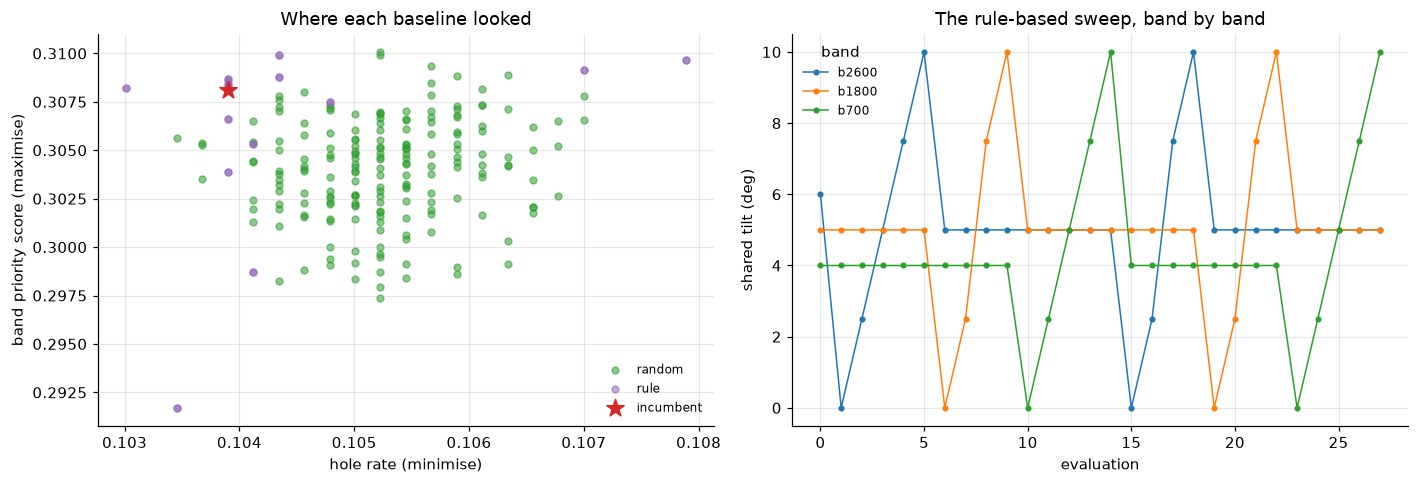

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

colours = {"random": "tab:green", "rule": "tab:purple"}
for method, history in runs.items():
    f = history.frame()
    axes[0].scatter(
        f["hole_rate"], f["served_ratio"], s=20, alpha=0.55, c=colours[method], label=method
    )
axes[0].scatter(
    [incumbent.kpi.hole_rate],
    [incumbent.kpi.served_ratio],
    s=140,
    marker="*",
    c="tab:red",
    zorder=5,
    label="incumbent",
)
axes[0].set(
    xlabel="hole rate (minimise)",
    ylabel="served ratio (maximise)",
    title="Where each baseline looked",
)
axes[0].legend(fontsize=8)

# The rule sweep is one-dimensional per band, so its trace is readable directly.
rule = runs["rule"].frame()
for band in space.band_names:
    column = f"tilt_{space.cells[0].name}_{band}"
    axes[1].plot(rule.index, rule[column], marker=".", lw=1, label=band)
axes[1].set(
    xlabel="evaluation", ylabel="shared tilt (deg)", title="The rule-based sweep, band by band"
)
axes[1].legend(fontsize=8, title="band")
fig.tight_layout()
save_fig(fig, "where_the_baselines_looked")

## 6. Persist

Both runs, into the same layout `03b_turbo.ipynb` writes, so the three are
readable side by side.


In [10]:
from src.optim.run import output_directory

for method, history in runs.items():
    directory = output_directory(configs[method], method)
    publish(
        history,
        configs[method],
        directory,
        method,
        extra={
            "scenario_id": evaluator.scenario_id,
            "notebook": "03a_baseline.ipynb",
        },
    )
    print(f"{method:>7}: {directory}")


random: 8 solutions published

 solution  recommended   score  hole_rate  overlap_rate  band_priority_score  weak_rate
        0         True -0.8058     0.1039        0.2955               0.3081     0.1198
        1        False -0.8174     0.1052        0.2986               0.3101     0.1207
        2        False -0.8199     0.1052        0.2991               0.3099     0.1216
        3        False -0.8248     0.1057        0.2962               0.3048     0.1232
        4        False -0.8259     0.1050        0.2984               0.3049     0.1205
        5        False -0.8270     0.1059        0.2986               0.3068     0.1212
        6        False -0.8277     0.1057        0.3008               0.3085     0.1194
        7        False -0.8317     0.1046        0.3026               0.3080     0.1216

wrote outputs\optim\random\2026-09-14_03-40-57
  history: outputs\optim\random\2026-09-14_03-40-57\history.parquet
  best_tilt: outputs\optim\random\2026-09-14_03-40-57\best_t

## 7. All methods side by side

Reads whatever runs exist under `outputs/optim/`, so this table fills in as
`03b_turbo.ipynb` is run. Compare on evaluations **and** on wall clock: the
methods are matched on the first and nowhere near matched on the second.


In [11]:
import json
from pathlib import Path

rows = []
for path in sorted(Path(cfg.optim.output.dir).glob("*/*/run.json")):
    run = json.loads(path.read_text(encoding="utf-8"))
    rows.append(
        {
            "method": run["method"],
            "run": path.parent.name,
            "evaluations": run["n_evaluations"],
            "minutes": round(run.get("wall_clock_seconds", float("nan")) / 60, 1),
            **{name: round(value, 4) for name, value in run["best_kpi"].items()},
        }
    )

if not rows:
    print("no runs under", cfg.optim.output.dir)
else:
    summary = pd.DataFrame(rows).sort_values(["method", "run"]).reset_index(drop=True)
    save_table(summary, "methods_side_by_side")
    display(summary)

,method,run,evaluations,minutes,hole_rate,overlap_rate,band_priority_score,weak_rate
0,random,2026-09-13_06-21-55,161,19.7,0.0000,0.4404,0.3097,0.0253
1,random,2026-09-14_01-40-24,161,NaN,0.1052,0.2986,0.3101,0.1207
2,random,2026-09-14_03-40-57,193,NaN,0.1039,0.2955,0.3081,0.1198
3,rule,2026-09-12_10-15-25,28,3.2,0.0000,0.4315,0.2965,0.0230
4,rule,2026-09-12_10-20-14,28,3.1,0.0000,0.4315,0.2965,0.0230
5,rule,2026-09-13_06-41-45,27,2.9,0.0000,0.4311,0.2969,0.0230
6,rule,2026-09-14_01-40-24,29,NaN,0.1039,0.2931,0.3085,0.1198
7,rule,2026-09-14_03-40-57,28,NaN,0.1039,0.2931,0.3085,0.1198
8,turbo,2026-09-13_05-56-15,161,25.6,0.0000,0.4176,0.3035,0.0257
9,turbo,2026-09-14_02-15-17,161,NaN,0.1050,0.2909,0.3095,0.1198


## 9. Handoff checklist

- [ ] The incumbent's KPIs matched `data/interim/radio_map.npz`
- [ ] Random search ran at the same `optim.method.budget` as the Bayesian run
- [ ] Every evaluated tilt stayed inside the committed bounds
- [ ] The four KPIs came from `src/kpi/`, with no threshold restated here
- [ ] Each winner was chosen by the ADR 0001 single pass
- [ ] Wall clock was recorded, not only the evaluation count
- [ ] Both run directories hold history, solutions, best_tilt, best_radio_map and run.json
